<a href="https://colab.research.google.com/github/abyanmaheswara/Prediksi-Kelanggengan-Hubungan-Pernikahanan/blob/main/Train_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

print("✅ Library berhasil di-import!")


✅ Library berhasil di-import!


In [2]:
from google.colab import files
uploaded = files.upload()  # Upload file marriage_longevity_master.csv

df = pd.read_csv("marriage_longevity_master.csv")
print(f"✅ Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


Saving marriage_longevity_master.csv to marriage_longevity_master.csv
✅ Dataset berhasil dimuat: 45000 baris, 24 kolom


,marriage_id,marriage_number,age_at_marriage,age_gap_years,education_level,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,...,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
0,MAR000000,1,36,6,less_than_hs,68600.0,5.9,1,1,0,...,7.7,5.8,8.1,4.1,2.22,3.0,4.0,22.0,NaN,0
1,MAR000001,2,59,1,some_college,328800.0,0.0,1,1,0,...,1.7,6.8,3.0,5.1,11.99,1.0,1.0,15.5,NaN,0
2,MAR000002,2,44,1,high_school,139900.0,6.1,0,0,1,...,6.5,4.2,4.8,5.7,2.27,4.0,2.0,7.2,NaN,0
3,MAR000003,1,25,2,bachelors,97600.0,5.9,1,1,1,...,0.0,4.1,0.9,8.7,6.24,0.0,4.0,13.5,NaN,0
4,MAR000004,2,29,3,graduate,98200.0,4.0,0,0,1,...,4.4,4.6,9.6,8.9,2.59,4.0,5.0,7.5,7.5,1


In [3]:
print("="*60)
print("PREPROCESSING DATA")
print("="*60)

# Hapus fitur yang menyebabkan data leakage dan ID non-prediktif
kolom_hapus = ['years_to_divorce', 'marriage_id']
target = 'divorced'

X = df.drop(columns=kolom_hapus + [target])
y = df[target]

print(f"Fitur yang digunakan ({len(X.columns)}):")
print(list(X.columns))

# Label Encoding untuk kolom kategorikal
encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le
    print(f"Encoded '{col}': {list(le.classes_)}")

features = list(X.columns)


PREPROCESSING DATA
Fitur yang digunakan (21):
['marriage_number', 'age_at_marriage', 'age_gap_years', 'education_level', 'household_income_usd', 'financial_stress', 'both_employed', 'cohabited_before', 'premarital_counseling', 'child_before_marriage', 'n_children', 'religious_attendance', 'criticism', 'contempt', 'defensiveness', 'stonewalling', 'repair_attempt_success', 'positive_negative_ratio', 'conflict_frequency_weekly', 'shared_activities_weekly', 'years_married']
Encoded 'education_level': ['bachelors', 'graduate', 'high_school', 'less_than_hs', 'some_college']
Encoded 'religious_attendance': ['monthly', 'never', 'rarely', 'weekly']


ANALISIS IMBALANCED DATA & PROSES SMOTE
Distribusi Target Sebelum SMOTE:
  • Langgeng (0): 24292 data (54.0%)
  • Cerai    (1): 20708 data (46.0%)

>> Menjalankan SMOTE (Synthetic Minority Over-sampling Technique)...

Distribusi Target Setelah SMOTE:
  • Langgeng (0): 24292 data (50.0%)
  • Cerai    (1): 24292 data (50.0%)


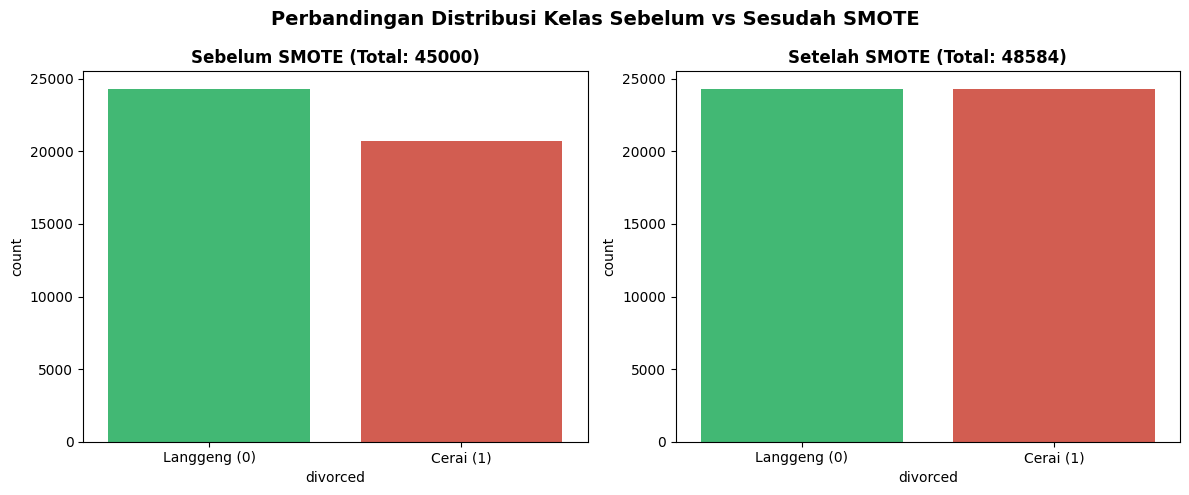

In [4]:
print("="*60)
print("ANALISIS IMBALANCED DATA & PROSES SMOTE")
print("="*60)

count_0 = (y == 0).sum()
count_1 = (y == 1).sum()
pct_0 = count_0 / len(y) * 100
pct_1 = count_1 / len(y) * 100

print(f"Distribusi Target Sebelum SMOTE:")
print(f"  • Langgeng (0): {count_0} data ({pct_0:.1f}%)")
print(f"  • Cerai    (1): {count_1} data ({pct_1:.1f}%)")

# Menerapkan SMOTE untuk menyeimbangkan kelas secara sempurna (1:1)
print("\n>> Menjalankan SMOTE (Synthetic Minority Over-sampling Technique)...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

count_0_after = (y_resampled == 0).sum()
count_1_after = (y_resampled == 1).sum()

print(f"\nDistribusi Target Setelah SMOTE:")
print(f"  • Langgeng (0): {count_0_after} data ({count_0_after/len(y_resampled)*100:.1f}%)")
print(f"  • Cerai    (1): {count_1_after} data ({count_1_after/len(y_resampled)*100:.1f}%)")

# Visualisasi perbandingan Sebelum vs Sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'Sebelum SMOTE (Total: {len(y)})', fontweight='bold')
axes[0].set_xticklabels(['Langgeng (0)', 'Cerai (1)'])

sns.countplot(x=y_resampled, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'Setelah SMOTE (Total: {len(y_resampled)})', fontweight='bold')
axes[1].set_xticklabels(['Langgeng (0)', 'Cerai (1)'])

plt.suptitle('Perbandingan Distribusi Kelas Sebelum vs Sesudah SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gunakan data hasil SMOTE untuk tahap training
X_final, y_final = X_resampled, y_resampled


In [5]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)
print(f"Jumlah Data Training : {len(X_train)} baris")
print(f"Jumlah Data Testing  : {len(X_test)} baris")

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Normalisasi (StandardScaler) selesai!")


Jumlah Data Training : 38867 baris
Jumlah Data Testing  : 9717 baris
✅ Normalisasi (StandardScaler) selesai!


In [6]:
print("="*60)
print("TRAINING 4 ALGORITMA MACHINE LEARNING")
print("="*60)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5),
}

results = []

for name, model in models.items():
    print(f"Sedang melatih {name}...", end=" ")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "model_obj": model
    })
    print(f"Selesai! (Accuracy: {acc*100:.2f}%)")


TRAINING 4 ALGORITMA MACHINE LEARNING
Sedang melatih Decision Tree... Selesai! (Accuracy: 73.61%)
Sedang melatih Random Forest... Selesai! (Accuracy: 79.53%)
Sedang melatih Logistic Regression... Selesai! (Accuracy: 78.65%)
Sedang melatih Gradient Boosting... Selesai! (Accuracy: 80.12%)


TABEL PERBANDINGAN HASIL
              Model  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting    80.12%     79.25%  81.60%    80.41%
      Random Forest    79.53%     78.32%  81.66%    79.96%
Logistic Regression    78.65%     77.94%  79.91%    78.91%
      Decision Tree    73.61%     71.86%  77.62%    74.63%


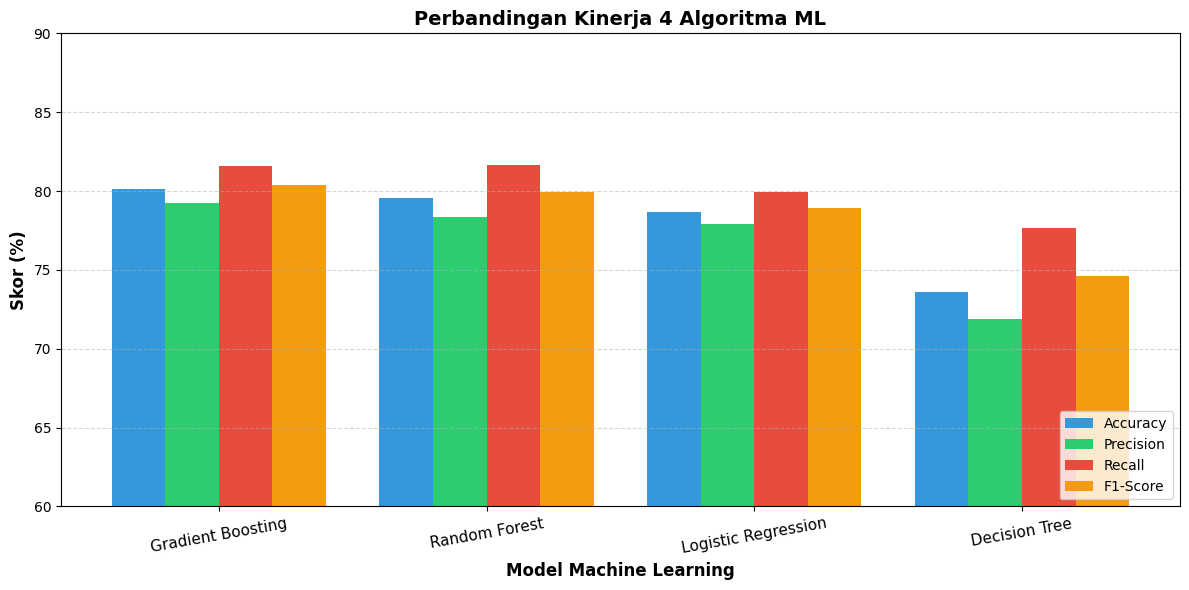

In [7]:
print("="*60)
print("TABEL PERBANDINGAN HASIL")
print("="*60)

df_results = pd.DataFrame(results)[["Model", "Accuracy", "Precision", "Recall", "F1-Score"]]
df_results_sorted = df_results.sort_values("Accuracy", ascending=False)
print(df_results_sorted.to_string(index=False, float_format=lambda x: f"{x*100:.2f}%"))

# Visualisasi Bar Chart Perbandingan 4 Metrik
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_results_sorted))
width = 0.2

ax.bar(x - 1.5*width, df_results_sorted['Accuracy']*100, width, label='Accuracy', color='#3498db')
ax.bar(x - 0.5*width, df_results_sorted['Precision']*100, width, label='Precision', color='#2ecc71')
ax.bar(x + 0.5*width, df_results_sorted['Recall']*100, width, label='Recall', color='#e74c3c')
ax.bar(x + 1.5*width, df_results_sorted['F1-Score']*100, width, label='F1-Score', color='#f39c12')

ax.set_xlabel('Model Machine Learning', fontweight='bold', fontsize=12)
ax.set_ylabel('Skor (%)', fontweight='bold', fontsize=12)
ax.set_title('Perbandingan Kinerja 4 Algoritma ML', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results_sorted['Model'], rotation=10, fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(60, 90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🏆 MODEL TERBAIK YANG DIPILIH: Gradient Boosting (Akurasi: 80.12%)

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

    Langgeng       0.81      0.79      0.80      4859
       Cerai       0.79      0.82      0.80      4858

    accuracy                           0.80      9717
   macro avg       0.80      0.80      0.80      9717
weighted avg       0.80      0.80      0.80      9717



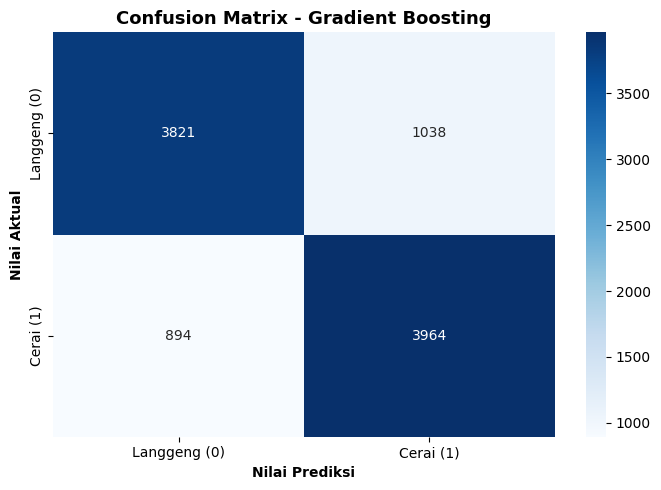

In [8]:
best_idx = df_results["Accuracy"].idxmax()
best_name = results[best_idx]["Model"]
best_model = results[best_idx]["model_obj"]
best_acc = results[best_idx]["Accuracy"]

print(f"🏆 MODEL TERBAIK YANG DIPILIH: {best_name} (Akurasi: {best_acc*100:.2f}%)\n")

# Classification Report
y_pred_best = best_model.predict(X_test_scaled)
print(f"Classification Report ({best_name}):")
print(classification_report(y_test, y_pred_best, target_names=["Langgeng", "Cerai"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Langgeng (0)", "Cerai (1)"],
            yticklabels=["Langgeng (0)", "Cerai (1)"])
plt.title(f'Confusion Matrix - {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Nilai Aktual', fontweight='bold')
plt.xlabel('Nilai Prediksi', fontweight='bold')
plt.tight_layout()
plt.show()


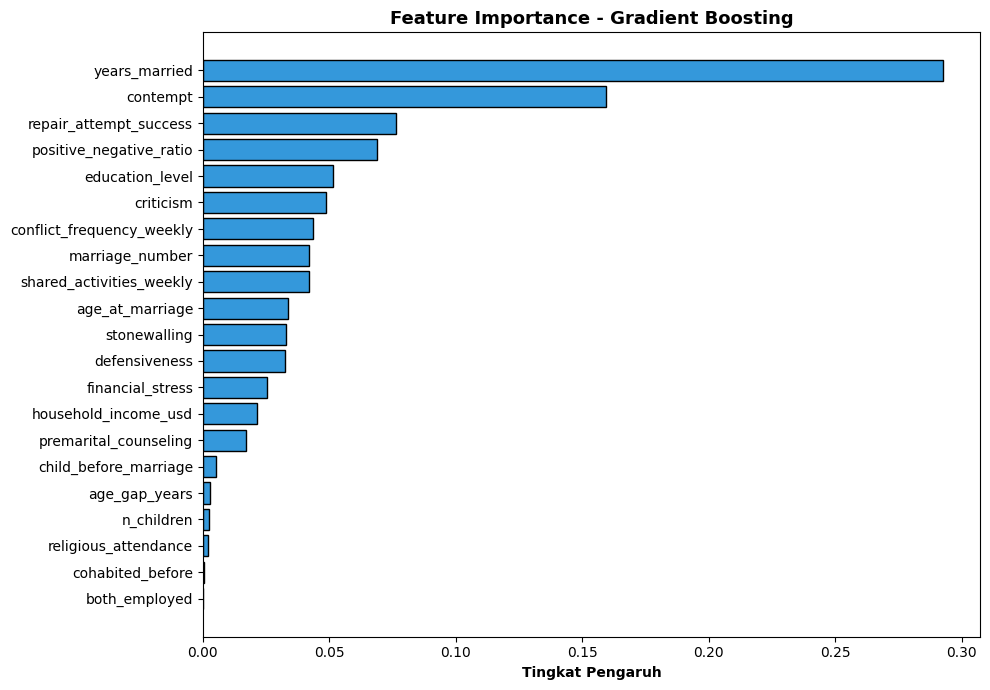

Top 5 Faktor Paling Berpengaruh:
                  Fitur  Importance
          years_married    0.292657
               contempt    0.159523
 repair_attempt_success    0.076185
positive_negative_ratio    0.068762
        education_level    0.051458


In [9]:
if hasattr(best_model, "feature_importances_"):
    imp = pd.DataFrame({
        'Fitur': features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(imp['Fitur'], imp['Importance'], color='#3498db', edgecolor='black')
    plt.title(f'Feature Importance - {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Tingkat Pengaruh', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Top 5 Faktor Paling Berpengaruh:")
    print(imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))


In [10]:
# Buat folder artifacts
os.makedirs("artifacts", exist_ok=True)

# Simpan semua komponen yang dibutuhkan web app
joblib.dump(best_model, "artifacts/best_model.pkl")
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(encoders, "artifacts/encoders.pkl")
joblib.dump(features, "artifacts/features.pkl")

print(f"✅ Model terbaik ({best_name}) beserta scaler dan encoders berhasil disimpan ke folder 'artifacts/'!")

# Compress ke zip dan download otomatis ke laptop
shutil.make_archive("artifacts", 'zip', "artifacts")
from google.colab import files
files.download("artifacts.zip")
print("✅ File artifacts.zip siap dipakai untuk Streamlit!")


✅ Model terbaik (Gradient Boosting) beserta scaler dan encoders berhasil disimpan ke folder 'artifacts/'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File artifacts.zip siap dipakai untuk Streamlit!
